In [1]:
# load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load all data (2014-2022)
meps = pd.read_csv("data/integrated_data.csv")

C:\Users\vgmay\AppData\Local\Temp\ipykernel_12188\3427051443.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  meps = pd.read_csv("integrated_data.csv")


In [4]:
# randomly sample rows from dataset to make model more manageable
meps = meps.sample(n=100000, random_state=42)

In [5]:
# remove rows with Inf (had division by zero due to unexpected zeros)
meps = meps[~meps.isin([np.inf, -np.inf]).any(axis=1)]

In [6]:
# view columns
print(meps.columns)

Index(['Unnamed: 0', 'Year', 'Person.ID', 'Drug', 'Quantity', 'Form',
       'Strength', 'Day_Supply', 'Sum.of.all.payments', 'Administration_route',
       'Daily_Frequency', 'Daily_Dosage', 'Age', 'Sex', 'Ethnicity', 'Race',
       'Personal_income', 'Family_income', 'Poverty_category',
       'Can.t_get_PMED', 'Insurance_coverage', 'PMED_insurance_coverage',
       'Concentration', 'Concentration_Level', 'Vet_drug', 'OTC_drug',
       'Abuse_potential'],
      dtype='object')


In [7]:
# fix columns with apostrophe
meps.rename(columns=lambda x: x.replace("'", "_"), inplace=True)

In [8]:
# view columns
print(meps.columns)

Index(['Unnamed: 0', 'Year', 'Person.ID', 'Drug', 'Quantity', 'Form',
       'Strength', 'Day_Supply', 'Sum.of.all.payments', 'Administration_route',
       'Daily_Frequency', 'Daily_Dosage', 'Age', 'Sex', 'Ethnicity', 'Race',
       'Personal_income', 'Family_income', 'Poverty_category',
       'Can.t_get_PMED', 'Insurance_coverage', 'PMED_insurance_coverage',
       'Concentration', 'Concentration_Level', 'Vet_drug', 'OTC_drug',
       'Abuse_potential'],
      dtype='object')


In [9]:
# drop columns not needed for random forest model
meps = meps.drop(['Unnamed: 0', 'Person.ID', 'Quantity', 'Form',
                  'Strength',"Day_Supply",
                  'Sum.of.all.payments',
                  'Administration_route', 'Daily_Frequency', 'Daily_Dosage', 'Concentration_Level',
                  'Vet_drug','OTC_drug','Abuse_potential'], axis=1)

In [10]:
meps.head(10)

,Year,Drug,Age,Sex,Ethnicity,Race,Personal_income,Family_income,Poverty_category,Can.t_get_PMED,Insurance_coverage,PMED_insurance_coverage,Concentration
245449,2014,hydroxyzine,56.0,2.0,1.0,1.0,8424.0,16848.0,2.0,2.0,2.0,2.0,0.000403
290230,2014,minocycline,23.0,2.0,1.0,1.0,8600.0,43000.0,3.0,2.0,1.0,1.0,0.000805
695003,2018,carvedilol,63.0,2.0,1.0,1.0,12000.0,12000.0,1.0,2.0,2.0,2.0,0.000101
1260155,2021,furosemide,67.0,2.0,2.0,1.0,17220.0,34440.0,4.0,2.0,4.0,2.0,0.000484
1438336,2022,losartan,85.0,2.0,2.0,1.0,50966.0,166660.0,5.0,2.0,5.0,1.0,0.000271
195873,2014,acyclovir,56.0,2.0,1.0,1.0,17651.0,35301.0,4.0,2.0,1.0,1.0,0.032216
972571,2020,gabapentin,38.0,1.0,2.0,1.0,13609.0,13609.0,2.0,2.0,2.0,2.0,0.009665
263920,2014,glimepiride,81.0,2.0,2.0,1.0,42326.0,84651.0,5.0,2.0,5.0,2.0,0.000015
764506,2018,furosemide,75.0,1.0,2.0,1.0,20500.0,41000.0,4.0,2.0,4.0,2.0,0.001104
345128,2016,atorvastatin,61.0,2.0,5.0,12.0,8400.0,8400.0,1.0,2.0,2.0,2.0,0.000322


In [11]:
# move drug to end with concentration 
cols = list(meps.columns)
cols.remove('Drug')  
cols.insert(-1, 'Drug')  
meps = meps[cols]

In [12]:
meps.head(10)

,Year,Age,Sex,Ethnicity,Race,Personal_income,Family_income,Poverty_category,Can.t_get_PMED,Insurance_coverage,PMED_insurance_coverage,Drug,Concentration
245449,2014,56.0,2.0,1.0,1.0,8424.0,16848.0,2.0,2.0,2.0,2.0,hydroxyzine,0.000403
290230,2014,23.0,2.0,1.0,1.0,8600.0,43000.0,3.0,2.0,1.0,1.0,minocycline,0.000805
695003,2018,63.0,2.0,1.0,1.0,12000.0,12000.0,1.0,2.0,2.0,2.0,carvedilol,0.000101
1260155,2021,67.0,2.0,2.0,1.0,17220.0,34440.0,4.0,2.0,4.0,2.0,furosemide,0.000484
1438336,2022,85.0,2.0,2.0,1.0,50966.0,166660.0,5.0,2.0,5.0,1.0,losartan,0.000271
195873,2014,56.0,2.0,1.0,1.0,17651.0,35301.0,4.0,2.0,1.0,1.0,acyclovir,0.032216
972571,2020,38.0,1.0,2.0,1.0,13609.0,13609.0,2.0,2.0,2.0,2.0,gabapentin,0.009665
263920,2014,81.0,2.0,2.0,1.0,42326.0,84651.0,5.0,2.0,5.0,2.0,glimepiride,0.000015
764506,2018,75.0,1.0,2.0,1.0,20500.0,41000.0,4.0,2.0,4.0,2.0,furosemide,0.001104
345128,2016,61.0,2.0,5.0,12.0,8400.0,8400.0,1.0,2.0,2.0,2.0,atorvastatin,0.000322


In [13]:
# encode Drug variable
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
meps['Drug'] = encoder.fit_transform(meps['Drug'])
meps.head(10)

,Year,Age,Sex,Ethnicity,Race,Personal_income,Family_income,Poverty_category,Can.t_get_PMED,Insurance_coverage,PMED_insurance_coverage,Drug,Concentration
245449,2014,56.0,2.0,1.0,1.0,8424.0,16848.0,2.0,2.0,2.0,2.0,171,0.000403
290230,2014,23.0,2.0,1.0,1.0,8600.0,43000.0,3.0,2.0,1.0,1.0,240,0.000805
695003,2018,63.0,2.0,1.0,1.0,12000.0,12000.0,1.0,2.0,2.0,2.0,55,0.000101
1260155,2021,67.0,2.0,2.0,1.0,17220.0,34440.0,4.0,2.0,4.0,2.0,154,0.000484
1438336,2022,85.0,2.0,2.0,1.0,50966.0,166660.0,5.0,2.0,5.0,1.0,216,0.000271
195873,2014,56.0,2.0,1.0,1.0,17651.0,35301.0,4.0,2.0,1.0,1.0,1,0.032216
972571,2020,38.0,1.0,2.0,1.0,13609.0,13609.0,2.0,2.0,2.0,2.0,155,0.009665
263920,2014,81.0,2.0,2.0,1.0,42326.0,84651.0,5.0,2.0,5.0,2.0,158,0.000015
764506,2018,75.0,1.0,2.0,1.0,20500.0,41000.0,4.0,2.0,4.0,2.0,154,0.001104
345128,2016,61.0,2.0,5.0,12.0,8400.0,8400.0,1.0,2.0,2.0,2.0,23,0.000322


In [14]:
# split into train and test sets
from sklearn.model_selection import train_test_split
X = meps.drop(meps.columns[-2:], axis=1)
y = meps['Drug']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape)
print(y_train.shape, y_test.shape)

(79996, 11) (19999, 11)
(79996,) (19999,)


In [14]:
# implement random forest classifier (NOTE: this is the model with the best output so far)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# model evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.26
Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.07      0.08        92
           1       0.20      0.12      0.15        25
           3       0.17      0.17      0.17       397
           4       0.17      0.18      0.18        60
           5       0.00      0.00      0.00         5
           6       0.06      0.04      0.05        98
           7       0.00      0.00      0.00         2
           8       0.17      0.18      0.17       117
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00        20
          11       0.11      0.08      0.09        62
          12       0.14      0.11      0.13       535
          13       0.11      0.20      0.14         5
          14       0.10      0.09      0.10       138
          16       0.00      0.00      0.00         2
          17       0.24      0.22      0.23        18
          18       0.22      0.18      0.20

c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

In [15]:
# decode Drug variable
encoded_drugs_pred = y_pred
decoded_drugs = encoder.inverse_transform(encoded_drugs_pred)

In [ ]:
# test the impact of removing age from model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
X_a = X.drop('Age', axis=1)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_a, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_a, y)
y_pred_a = clf.predict(X_test_a)

# model evaluation
accuracy = accuracy_score(y_test_a, y_pred_a)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test_a, y_pred_a))

Accuracy: 0.60
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.45      0.52        92
           1       0.78      0.56      0.65        25
           3       0.57      0.51      0.54       397
           4       0.52      0.62      0.56        60
           5       1.00      0.80      0.89         5
           6       0.59      0.45      0.51        98
           7       0.00      0.00      0.00         2
           8       0.57      0.55      0.56       117
           9       1.00      1.00      1.00         1
          10       0.40      0.10      0.16        20
          11       0.54      0.47      0.50        62
          12       0.62      0.51      0.56       535
          13       0.50      0.20      0.29         5
          14       0.86      0.73      0.79       138
          16       1.00      0.50      0.67         2
          17       0.61      0.61      0.61        18
          18       0.56      0.53      0.54

c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

In [15]:
# test the impact of removing sex from model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
X_s = X.drop('Sex', axis=1)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_s, y)
y_pred_s = clf.predict(X_test_s)

# model evaluation
accuracy = accuracy_score(y_test_s, y_pred_s)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test_s, y_pred_s))

Accuracy: 0.62
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.47      0.53        92
           1       0.74      0.56      0.64        25
           3       0.61      0.54      0.57       397
           4       0.53      0.63      0.58        60
           5       1.00      0.80      0.89         5
           6       0.62      0.44      0.51        98
           7       1.00      0.50      0.67         2
           8       0.57      0.55      0.56       117
           9       1.00      1.00      1.00         1
          10       0.29      0.10      0.15        20
          11       0.58      0.50      0.54        62
          12       0.63      0.53      0.57       535
          13       1.00      0.20      0.33         5
          14       0.86      0.78      0.82       138
          16       1.00      0.50      0.67         2
          17       0.61      0.61      0.61        18
          18       0.53      0.51      0.52

c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

In [16]:
# test the impact of removing ethnicity from model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
X_e = X.drop('Ethnicity', axis=1)
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_e, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_e, y)
y_pred_e = clf.predict(X_test_e)

# model evaluation
accuracy = accuracy_score(y_test_e, y_pred_e)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test_e, y_pred_e))

Accuracy: 0.62
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.46      0.53        92
           1       0.74      0.56      0.64        25
           3       0.62      0.53      0.57       397
           4       0.51      0.63      0.57        60
           5       1.00      0.80      0.89         5
           6       0.62      0.46      0.53        98
           7       1.00      0.50      0.67         2
           8       0.56      0.55      0.55       117
           9       1.00      1.00      1.00         1
          10       0.40      0.10      0.16        20
          11       0.58      0.50      0.54        62
          12       0.63      0.53      0.58       535
          13       1.00      0.20      0.33         5
          14       0.86      0.78      0.82       138
          16       1.00      0.50      0.67         2
          17       0.63      0.67      0.65        18
          18       0.54      0.54      0.54

c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

In [15]:
# test the impact of removing race from model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
X_r = X.drop('Race', axis=1)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_r, y)
y_pred_r = clf.predict(X_test_r)

# model evaluation
accuracy = accuracy_score(y_test_r, y_pred_r)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test_r, y_pred_r))

Accuracy: 0.62
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.47      0.53        92
           1       0.74      0.56      0.64        25
           3       0.61      0.54      0.57       397
           4       0.51      0.63      0.57        60
           5       1.00      0.80      0.89         5
           6       0.62      0.46      0.53        98
           7       1.00      0.50      0.67         2
           8       0.56      0.55      0.55       117
           9       1.00      1.00      1.00         1
          10       0.40      0.10      0.16        20
          11       0.57      0.50      0.53        62
          12       0.64      0.53      0.58       535
          13       1.00      0.20      0.33         5
          14       0.87      0.79      0.83       138
          16       1.00      0.50      0.67         2
          17       0.63      0.67      0.65        18
          18       0.54      0.54      0.54

c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

Top 10 predicted drugs:             Drug  Count
0     furosemide   3406
1      meloxicam   1639
2     omeprazole    827
3   atorvastatin    637
4  levothyroxine    582
5     lisinopril    567
6      metformin    528
7     amlodipine    446
8     metoprolol    391
9      albuterol    350
Top 10 actual drugs:             Drug  Count
0     furosemide   2246
1      meloxicam   1184
2     omeprazole    772
3     lisinopril    657
4   atorvastatin    653
5  levothyroxine    630
6      metformin    587
7     amlodipine    535
8     metoprolol    468
9      albuterol    397


C:\Users\vgmay\AppData\Local\Temp\ipykernel_12188\4207922195.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Drug', data=top_10_preds, ax=axes[0], palette=color_dict)
C:\Users\vgmay\AppData\Local\Temp\ipykernel_12188\4207922195.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Drug', data=top_10_test, ax=axes[1], palette=color_dict)


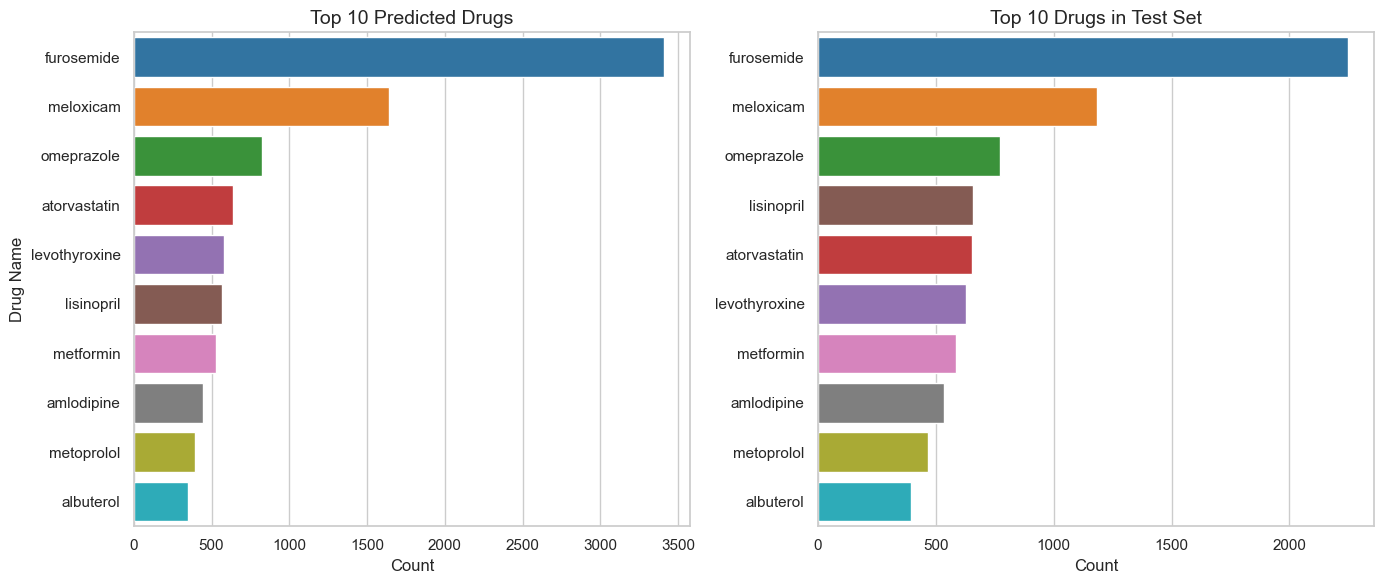

In [34]:
# NOTE: output from model with race removed is best model so far (model with ethnicity removed gives same metric scores), recall prioritized over precision

# plot side by side top 10 most frequently predicted drugs and top 10 most frequent drugs in test set
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# decode Drug variable
encoded_drugs_pred_r = y_pred_r
decoded_drugs_pred_r = encoder.inverse_transform(encoded_drugs_pred_r)

encoded_drugs_test_r = y_test_r
decoded_drugs_test_r = encoder.inverse_transform(encoded_drugs_test_r)

# Count occurrences
pred_counts = pd.Series(decoded_drugs_pred_r).value_counts().reset_index()
pred_counts.columns = ['Drug', 'Count']

test_counts = pd.Series(decoded_drugs_test_r).value_counts().reset_index()
test_counts.columns = ['Drug', 'Count']

top_10_preds = pred_counts.head(10)
top_10_test = test_counts.head(10)

print("Top 10 predicted drugs:", top_10_preds)
print("Top 10 actual drugs:", top_10_test)

# make color palette for drugs
all_drugs = pd.concat([top_10_preds['Drug'], top_10_test['Drug']]).drop_duplicates()
palette = sns.color_palette("tab10", n_colors=len(all_drugs))
color_dict = dict(zip(all_drugs, palette))

# Make the plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

sns.barplot(x='Count', y='Drug', data=top_10_preds, ax=axes[0], palette=color_dict)
axes[0].set_title('Top 10 Predicted Drugs', fontsize=14)
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('Drug Name', fontsize=12)

sns.barplot(x='Count', y='Drug', data=top_10_test, ax=axes[1], palette=color_dict)
axes[1].set_title('Top 10 Drugs in Test Set', fontsize=14)
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_ylabel('')  

plt.tight_layout()
plt.show()

C:\Users\vgmay\AppData\Local\Temp\ipykernel_12188\1620963396.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Drug', y='Count', data=pred_counts, ax=axes[0], palette=color_dict2, width=0.9)
C:\Users\vgmay\AppData\Local\Temp\ipykernel_12188\1620963396.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Drug', y='Count', data=test_counts, ax=axes[1], palette=color_dict2, width=0.9)


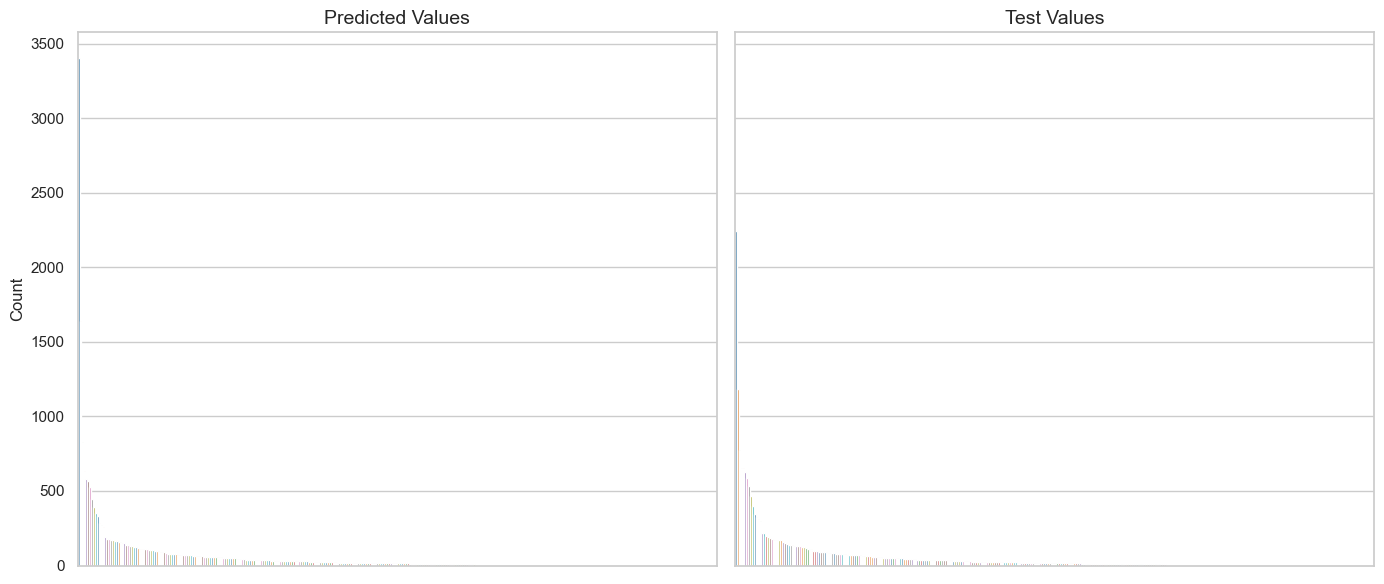

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Make color palette for drugs
all_drugs = pd.concat([pred_counts['Drug'], test_counts['Drug']]).unique()
palette = sns.color_palette("tab10", n_colors=len(all_drugs))
color_dict2 = dict(zip(all_drugs, palette))

# Create the plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.barplot(x='Drug', y='Count', data=pred_counts, ax=axes[0], palette=color_dict2, width=0.9)
axes[0].set_title('Predicted Values', fontsize=14)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels([])  

sns.barplot(x='Drug', y='Count', data=test_counts, ax=axes[1], palette=color_dict2, width=0.9)
axes[1].set_title('Test Values', fontsize=14)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_xticklabels([])  

plt.tight_layout()
plt.show()

C:\Users\vgmay\AppData\Local\Temp\ipykernel_12188\3650793488.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sample', y='Match', data=comparison_df, ci=None)


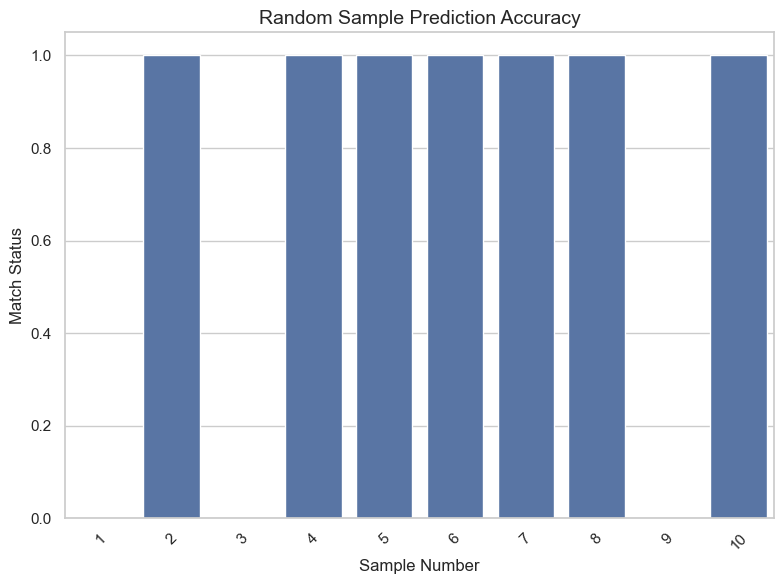

       Sample      Predicted         Actual  Match
7712        1  levothyroxine   methotrexate      0
19444       2   pantoprazole   pantoprazole      1
7224        3     lisinopril      metformin      0
14250       4     mirabegron     mirabegron      1
18735       5     omeprazole     omeprazole      1
4443        6     tamsulosin     tamsulosin      1
5050        7   azithromycin   azithromycin      1
8670        8      albuterol      albuterol      1
12529       9      nebivolol     amlodipine      0
3562       10  metronidazole  metronidazole      1


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# convert drug arrays to dataframes
decoded_drugs_pred_r = pd.DataFrame(decoded_drugs_pred_r, columns=['Drug'])
decoded_drugs_test_r = pd.DataFrame(decoded_drugs_test_r, columns=['Drug'])

# Randomly sample 10 rows (same index from both predicted and test sets)
random_indices = np.random.choice(decoded_drugs_pred_r.index, 10, replace=False)
pred_sample = decoded_drugs_pred_r.loc[random_indices]
test_sample = decoded_drugs_test_r.loc[random_indices]

# Compare the predictions with the actual test values (1 for match, 0 for mismatch)
comparison = (pred_sample['Drug'] == test_sample['Drug']).astype(int)
comparison_df = pd.DataFrame({
    'Sample': np.arange(1, 11),
    'Predicted': pred_sample['Drug'],
    'Actual': test_sample['Drug'],
    'Match': comparison
})

# Plot the results
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

sns.barplot(x='Sample', y='Match', data=comparison_df, ci=None)

plt.title('Random Sample Prediction Accuracy', fontsize=14)
plt.xlabel('Sample Number', fontsize=12)
plt.ylabel('Match Status', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(comparison_df)


In [ ]:
# test the impact of removing personal & family income & poverty category from model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
columns_to_drop = ['Personal_income', 'Family_income', 'Poverty_category']
X_i = X.drop(columns=columns_to_drop)
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_i, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_i, y)
y_pred_i = clf.predict(X_test_i)

# model evaluation
accuracy = accuracy_score(y_test_i, y_pred_i)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test_i, y_pred_i))

Accuracy: 0.32
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.23      0.33        92
           1       0.40      0.16      0.23        25
           3       0.38      0.30      0.34       397
           4       0.41      0.15      0.22        60
           5       0.00      0.00      0.00         5
           6       0.41      0.21      0.28        98
           7       0.00      0.00      0.00         2
           8       0.44      0.25      0.32       117
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00        20
          11       0.41      0.23      0.29        62
          12       0.32      0.21      0.25       535
          13       0.00      0.00      0.00         5
          14       0.55      0.35      0.43       138
          16       1.00      0.50      0.67         2
          17       0.43      0.17      0.24        18
          18       0.34      0.14      0.20

c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

In [16]:
# test the impact of removing insurance coverage variables from model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
columns_to_drop = ['Can.t_get_PMED', 'Insurance_coverage', 'PMED_insurance_coverage']
X_c = X.drop(columns=columns_to_drop)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_c, y)
y_pred_c = clf.predict(X_test_c)

# model evaluation
accuracy = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test_c, y_pred_c))

Accuracy: 0.62
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.47      0.53        92
           1       0.74      0.56      0.64        25
           3       0.61      0.54      0.57       397
           4       0.50      0.62      0.55        60
           5       1.00      0.80      0.89         5
           6       0.61      0.46      0.52        98
           7       1.00      0.50      0.67         2
           8       0.58      0.55      0.56       117
           9       1.00      1.00      1.00         1
          10       0.40      0.10      0.16        20
          11       0.57      0.50      0.53        62
          12       0.63      0.54      0.58       535
          13       1.00      0.20      0.33         5
          14       0.86      0.78      0.82       138
          16       1.00      0.50      0.67         2
          17       0.63      0.67      0.65        18
          18       0.53      0.53      0.53

c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

NOTE: The cells below are saved for later development. Several attempts were made to improve the model output before adjusting features, but their output was worse. The code is saved below to provide a reminder of what has been attempted so far and will be revisited after the conclusion of this class project.

In [ ]:
# attempt with different hyperparameters and stratified K fold (NOTE: this output is worse, best output is above)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

clf = RandomForestClassifier(random_state=42,n_estimators=300,max_depth=10, max_features='log2',min_samples_split=10)

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=skf)
print("Stratified K-Fold scores:", scores)

c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


Stratified K-Fold scores: [0.15284611 0.15090905]


In [ ]:
# Get predictions and accuracy after stratified K fold
all_predictions = []  
all_true_values = []  
fold_accuracies = []  

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    all_predictions.extend(y_pred)
    all_true_values.extend(y_test)
    
    fold_accuracy = accuracy_score(y_test, y_pred)
    fold_accuracies.append(fold_accuracy)

all_predictions = np.array(all_predictions)
all_true_values = np.array(all_true_values)

print("Fold Accuracies:", fold_accuracies)
print("Mean Accuracy:", np.mean(fold_accuracies))
print("All Predictions:", all_predictions)
print("All True Values:", all_true_values)    

c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


Fold Accuracies: [0.1528461138445538, 0.1509090545432726]
Mean Accuracy: 0.1518775841939132
All Predictions: [154 154 154 ... 224 154 154]
All True Values: [171 216 155 ... 224 154 156]


In [ ]:
# attempt with original hyperparameters and stratified K hold (NOTE: first attempt is still the best output)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

clf = RandomForestClassifier(random_state=42)

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=skf)
print("Stratified K-Fold scores:", scores)

c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


Stratified K-Fold scores: [0.22384895 0.22133328]


In [ ]:
# Get predictions and accuracy after stratified K fold
all_predictions = [] 
all_true_values = []  
fold_accuracies = []  

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    
    all_predictions.extend(y_pred)
    all_true_values.extend(y_test)
    
    fold_accuracy = accuracy_score(y_test, y_pred)
    fold_accuracies.append(fold_accuracy)

all_predictions = np.array(all_predictions)
all_true_values = np.array(all_true_values)

print("Fold Accuracies:", fold_accuracies)
print("Mean Accuracy:", np.mean(fold_accuracies))
print("All Predictions:", all_predictions)
print("All True Values:", all_true_values)    

c:\Users\vgmay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


Fold Accuracies: [0.22384895395815832, 0.2213332799967998]
Mean Accuracy: 0.22259111697747908
All Predictions: [295 224 126 ... 224 154  18]
All True Values: [171 216 155 ... 224 154 156]
